In [1]:
#importing relevant libraries
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
# Importing the MNIST dataset using TensorFlow Datasets
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)
# Splitting the dataset into training and testing sets
mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']

# Calculating the number of validation samples (10% of the training dataset)
num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)  # Convert to integer

# Calculating the number of test samples
num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)  # Convert to integer

# Function to scale the image data to a range of 0 to 1
def scale(image, label):
    image = tf.cast(image, tf.float32)  # Convert image to float32
    image /= 255.  # Normalize pixel values to range [0, 1]
    return image, label  # Return the scaled image and its corresponding label

# Apply scaling to the training and validation datasets
scaled_train_and_validation_data = mnist_train.map(scale)

# Apply scaling to the test dataset
test_data = mnist_test.map(scale)

# Defining a buffer size for shuffling the training and validation datasets
BUFFER_SIZE = 10000

# Shuffle the training and validation data for better training
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)

# Splitting the shuffled data into validation and training sets
validation_data = shuffled_train_and_validation_data.take(num_validation_samples)  # Take validation samples
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)  # Skip validation samples to get training data

# Setting the batch size for training
BATCH_SIZE = 100

# Batch the training data
train_data = train_data.batch(BATCH_SIZE)

# Batch the validation data (single batch containing all validation samples)
validation_data = validation_data.batch(num_validation_samples)

# Batch the test data (single batch containing all test samples)
test_data = test_data.batch(num_test_samples)

# Extract a single batch of validation data inputs and targets for evaluation
validation_inputs, validation_targets = next(iter(validation_data))


In [3]:
input_size = 784
output_size = 10
hidden_layer_size_1 =256
hidden_layer_size_2 =128
hidden_layer_size_3 =128


model = tf.keras.Sequential([
                            tf.keras.layers.Flatten(input_shape=(28,28,1)),
                            tf.keras.layers.Dense(hidden_layer_size_1, activation='sigmoid'), #1st hidden layer
                            tf.keras.layers.Dense(hidden_layer_size_2, activation='sigmoid'), #2nd hidden layer
                            tf.keras.layers.Dense(hidden_layer_size_3, activation='sigmoid'), #2nd hidden layer

                            tf.keras.layers.Dense(output_size, activation='softmax')   
                            ])

In [4]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [5]:
#train model
NUM_EPOCHS = 15
model.fit(train_data,epochs=NUM_EPOCHS,validation_data=(validation_inputs, validation_targets), verbose=2)

Epoch 1/15
540/540 - 12s - 22ms/step - accuracy: 0.8098 - loss: 0.6941 - val_accuracy: 0.9220 - val_loss: 0.2682
Epoch 2/15
540/540 - 5s - 9ms/step - accuracy: 0.9368 - loss: 0.2158 - val_accuracy: 0.9487 - val_loss: 0.1740
Epoch 3/15
540/540 - 5s - 9ms/step - accuracy: 0.9544 - loss: 0.1551 - val_accuracy: 0.9585 - val_loss: 0.1426
Epoch 4/15
540/540 - 7s - 12ms/step - accuracy: 0.9641 - loss: 0.1201 - val_accuracy: 0.9700 - val_loss: 0.1043
Epoch 5/15
540/540 - 7s - 12ms/step - accuracy: 0.9722 - loss: 0.0940 - val_accuracy: 0.9717 - val_loss: 0.0970
Epoch 6/15
540/540 - 5s - 10ms/step - accuracy: 0.9767 - loss: 0.0768 - val_accuracy: 0.9748 - val_loss: 0.0820
Epoch 7/15
540/540 - 7s - 13ms/step - accuracy: 0.9812 - loss: 0.0624 - val_accuracy: 0.9803 - val_loss: 0.0712
Epoch 8/15
540/540 - 5s - 10ms/step - accuracy: 0.9841 - loss: 0.0532 - val_accuracy: 0.9833 - val_loss: 0.0559
Epoch 9/15
540/540 - 5s - 10ms/step - accuracy: 0.9869 - loss: 0.0433 - val_accuracy: 0.9845 - val_loss: 

In [6]:
#test data
test_loss,test_accuracy = model.evaluate(test_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step - accuracy: 0.9792 - loss: 0.0790


In [7]:
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accuracy*100.))

Test loss: 0.08. Test accuracy: 97.92%


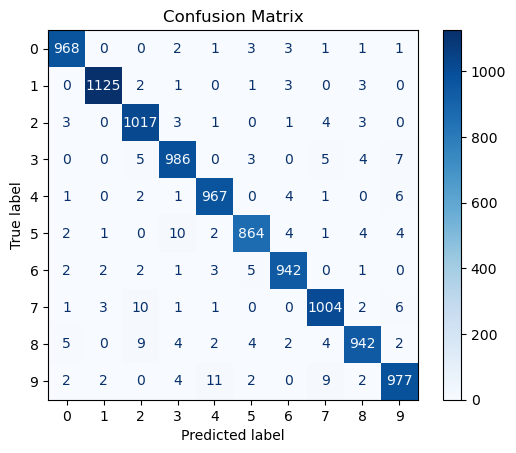

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Extract predictions and true labels
y_pred = []
y_true = []

# Iterate through the test dataset
for images, labels in test_data:
    predictions = model(images)  # Get model predictions
    predicted_classes = np.argmax(predictions.numpy(), axis=1)  # Convert to class indices
    y_pred.extend(predicted_classes)  # Append predictions
    y_true.extend(labels.numpy())  # Append true labels

# Convert to numpy arrays
y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))

# Plot confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()